In [20]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np

In [21]:
test_df = pd.read_csv("/users/imbahndu/Desktop/Columbia DBM/PFED5/Annotations/test_41.csv")

In [22]:
test_df

,videoID_subjectID,label,frame length,class,description
0,12-105227_0_003,2,30,0,sitting at rest
1,12-105227_1_003,2,55,1,smile
2,12-105227_2_003,2,96,2,frown
3,12-105227_3_003,2,104,3,squeeze eyes tightly
4,12-105230_0_003,3,14,0,sitting at rest
...,...,...,...,...,...
759,16-002607_0_063,2,31,0,sitting at rest
760,16-002607_1_063,3,125,1,smile
761,16-002607_2_063,4,106,2,frown
762,16-002607_3_063,2,94,3,squeeze eyes tightly


In [23]:
#Renaming the columns for consistency
test_df = test_df.rename(columns = {"label": "UPDRS_score", "class":"Task category"})

test_df

,videoID_subjectID,UPDRS_score,frame length,Task category,description
0,12-105227_0_003,2,30,0,sitting at rest
1,12-105227_1_003,2,55,1,smile
2,12-105227_2_003,2,96,2,frown
3,12-105227_3_003,2,104,3,squeeze eyes tightly
4,12-105230_0_003,3,14,0,sitting at rest
...,...,...,...,...,...
759,16-002607_0_063,2,31,0,sitting at rest
760,16-002607_1_063,3,125,1,smile
761,16-002607_2_063,4,106,2,frown
762,16-002607_3_063,2,94,3,squeeze eyes tightly


Joining df with images for CNN just like the train dataset

In [24]:
import glob
import os

# 2. Extract the folder name from videoID_subjectID
def find_image_folder(video_id):
    # E.g. video_id = "12-104704_0_001" → folder = "12-104704_0"
    base_id = "_".join(video_id.split("_")[:2])
    search_pattern = os.path.join("frames", "*", base_id)
    matches = glob.glob(search_pattern)
    return matches[0] if matches else None

test_df['image_folder_path'] = test_df['videoID_subjectID'].apply(find_image_folder)

# 3. Collect image paths from the folder
def get_image_paths(folder_path):
    if folder_path and os.path.exists(folder_path):
        return sorted(glob.glob(os.path.join(folder_path, '*.jpg')))
    return []

test_df['image_paths'] = test_df['image_folder_path'].apply(get_image_paths)

# 4. Select a main frame (e.g., the middle frame)
def get_main_frame(images):
    return images[len(images)//2] if images else None

test_df['main_frame'] = test_df['image_paths'].apply(get_main_frame)

# 5. Optionally filter out rows with no images
test_df = test_df[test_df['image_paths'].map(len) > 0].reset_index(drop=True)

# Done! You can now use df['main_frame'] or df['image_paths'] to feed into your CNN.
print(test_df.head())


  videoID_subjectID  UPDRS_score  frame length  Task category  \
0   12-105227_0_003            2            30              0   
1   12-105227_1_003            2            55              1   
2   12-105227_2_003            2            96              2   
3   12-105227_3_003            2           104              3   
4   12-105230_0_003            3            14              0   

            description       image_folder_path  \
0       sitting at rest  frames/003/12-105227_0   
1                 smile  frames/003/12-105227_1   
2                 frown  frames/003/12-105227_2   
3  squeeze eyes tightly  frames/003/12-105227_3   
4       sitting at rest  frames/003/12-105230_0   

                                         image_paths  \
0  [frames/003/12-105227_0/img_00001.jpg, frames/...   
1  [frames/003/12-105227_1/img_00001.jpg, frames/...   
2  [frames/003/12-105227_2/img_00001.jpg, frames/...   
3  [frames/003/12-105227_3/img_00001.jpg, frames/...   
4  [frames/003/12-1052

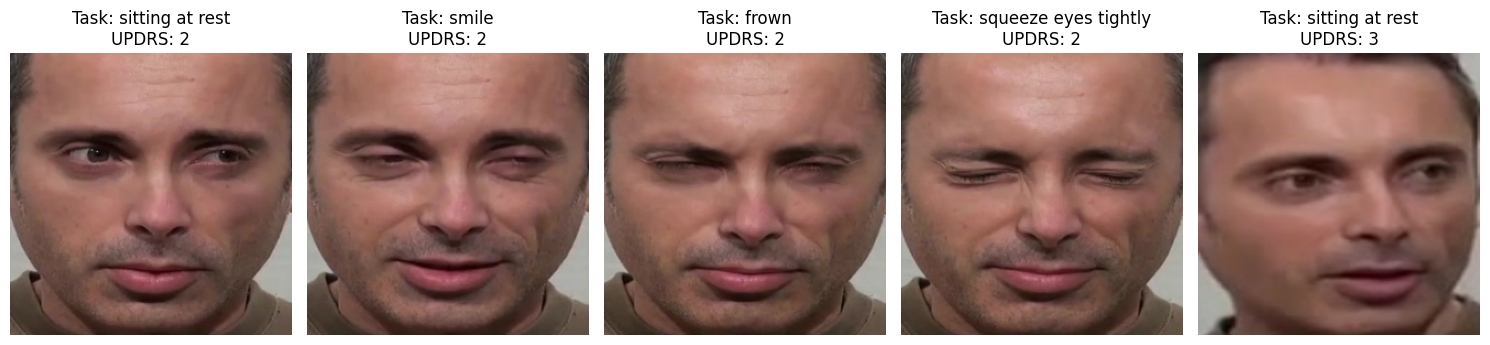

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image


# Filter only rows with valid main_frame entries
valid_rows = test_df[test_df['main_frame'].notnull()].head(5)  # Display first 5 with images

plt.figure(figsize=(15,5))

for i, (_, row) in enumerate(valid_rows.iterrows()):
    try:
        img = Image.open(row['main_frame'])
        plt.subplot(1, 5, i + 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Task: {row['description']}\nUPDRS: {row['UPDRS_score']}")
    except Exception as e:
        print(f"Failed to load image at {row['main_frame']}: {e}")

plt.tight_layout()
plt.show()

In [26]:
test_df

,videoID_subjectID,UPDRS_score,frame length,Task category,description,image_folder_path,image_paths,main_frame
0,12-105227_0_003,2,30,0,sitting at rest,frames/003/12-105227_0,"[frames/003/12-105227_0/img_00001.jpg, frames/...",frames/003/12-105227_0/img_00016.jpg
1,12-105227_1_003,2,55,1,smile,frames/003/12-105227_1,"[frames/003/12-105227_1/img_00001.jpg, frames/...",frames/003/12-105227_1/img_00028.jpg
2,12-105227_2_003,2,96,2,frown,frames/003/12-105227_2,"[frames/003/12-105227_2/img_00001.jpg, frames/...",frames/003/12-105227_2/img_00049.jpg
3,12-105227_3_003,2,104,3,squeeze eyes tightly,frames/003/12-105227_3,"[frames/003/12-105227_3/img_00001.jpg, frames/...",frames/003/12-105227_3/img_00053.jpg
4,12-105230_0_003,3,14,0,sitting at rest,frames/003/12-105230_0,"[frames/003/12-105230_0/img_00001.jpg, frames/...",frames/003/12-105230_0/img_00008.jpg
...,...,...,...,...,...,...,...,...
759,16-002607_0_063,2,31,0,sitting at rest,frames/063/16-002607_0,"[frames/063/16-002607_0/img_00001.jpg, frames/...",frames/063/16-002607_0/img_00016.jpg
760,16-002607_1_063,3,125,1,smile,frames/063/16-002607_1,"[frames/063/16-002607_1/img_00001.jpg, frames/...",frames/063/16-002607_1/img_00063.jpg
761,16-002607_2_063,4,106,2,frown,frames/063/16-002607_2,"[frames/063/16-002607_2/img_00001.jpg, frames/...",frames/063/16-002607_2/img_00054.jpg
762,16-002607_3_063,2,94,3,squeeze eyes tightly,frames/063/16-002607_3,"[frames/063/16-002607_3/img_00001.jpg, frames/...",frames/063/16-002607_3/img_00048.jpg


In [27]:
#Checking for null values

test_df.isnull().sum()

videoID_subjectID    0
UPDRS_score          0
frame length         0
Task category        0
description          0
image_folder_path    0
image_paths          0
main_frame           0
dtype: int64

In [28]:
#Confirming the datatypes
for col in test_df.columns:
    print(col , " ", test_df[col].dtype)

videoID_subjectID   object
UPDRS_score   int64
frame length   int64
Task category   int64
description   object
image_folder_path   object
image_paths   object
main_frame   object


In [29]:
#Dropping out columns that might not be predictive

test_df = test_df.drop(columns = ['videoID_subjectID', 'frame length', 'Task category', "image_folder_path", "image_paths"])

In [30]:
test_df

,UPDRS_score,description,main_frame
0,2,sitting at rest,frames/003/12-105227_0/img_00016.jpg
1,2,smile,frames/003/12-105227_1/img_00028.jpg
2,2,frown,frames/003/12-105227_2/img_00049.jpg
3,2,squeeze eyes tightly,frames/003/12-105227_3/img_00053.jpg
4,3,sitting at rest,frames/003/12-105230_0/img_00008.jpg
...,...,...,...
759,2,sitting at rest,frames/063/16-002607_0/img_00016.jpg
760,3,smile,frames/063/16-002607_1/img_00063.jpg
761,4,frown,frames/063/16-002607_2/img_00054.jpg
762,2,squeeze eyes tightly,frames/063/16-002607_3/img_00048.jpg


In [31]:
#One hot encoding the categorical columns 

test_df = pd.get_dummies(test_df, columns = ["description"], dtype = float)

In [32]:
test_df

,UPDRS_score,main_frame,description_clench the teeth,description_frown,description_sitting at rest,description_smile,description_squeeze eyes tightly
0,2,frames/003/12-105227_0/img_00016.jpg,0.0,0.0,1.0,0.0,0.0
1,2,frames/003/12-105227_1/img_00028.jpg,0.0,0.0,0.0,1.0,0.0
2,2,frames/003/12-105227_2/img_00049.jpg,0.0,1.0,0.0,0.0,0.0
3,2,frames/003/12-105227_3/img_00053.jpg,0.0,0.0,0.0,0.0,1.0
4,3,frames/003/12-105230_0/img_00008.jpg,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...
759,2,frames/063/16-002607_0/img_00016.jpg,0.0,0.0,1.0,0.0,0.0
760,3,frames/063/16-002607_1/img_00063.jpg,0.0,0.0,0.0,1.0,0.0
761,4,frames/063/16-002607_2/img_00054.jpg,0.0,1.0,0.0,0.0,0.0
762,2,frames/063/16-002607_3/img_00048.jpg,0.0,0.0,0.0,0.0,1.0


In [33]:
#Exporting df frame 

test_df.to_csv("test_cnn.csv", index=False)